In [ ]:
from torchvision import datasets
import torch

data_folder = '/content/data/FMNIST'  # thư mục lưu dataset
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)

tr_images = fmnist.data
tr_targets = fmnist.targets

unique_values = tr_targets.unique()

print(f"""tr_images & tr_targets:
    X - {tr_images.shape}
    Y - {tr_targets.shape}
    Y - Unique Values : {unique_values}
""")

print(f"TASK:\n\t{len(unique_values)} class Classification")
print(f"UNIQUE CLASSES:\n\t{fmnist.classes}")

tr_images & tr_targets:
    X - torch.Size([60000, 28, 28])
    Y - torch.Size([60000])
    Y - Unique Values : tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

TASK:
	10 class Classification
UNIQUE CLASSES:
	['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


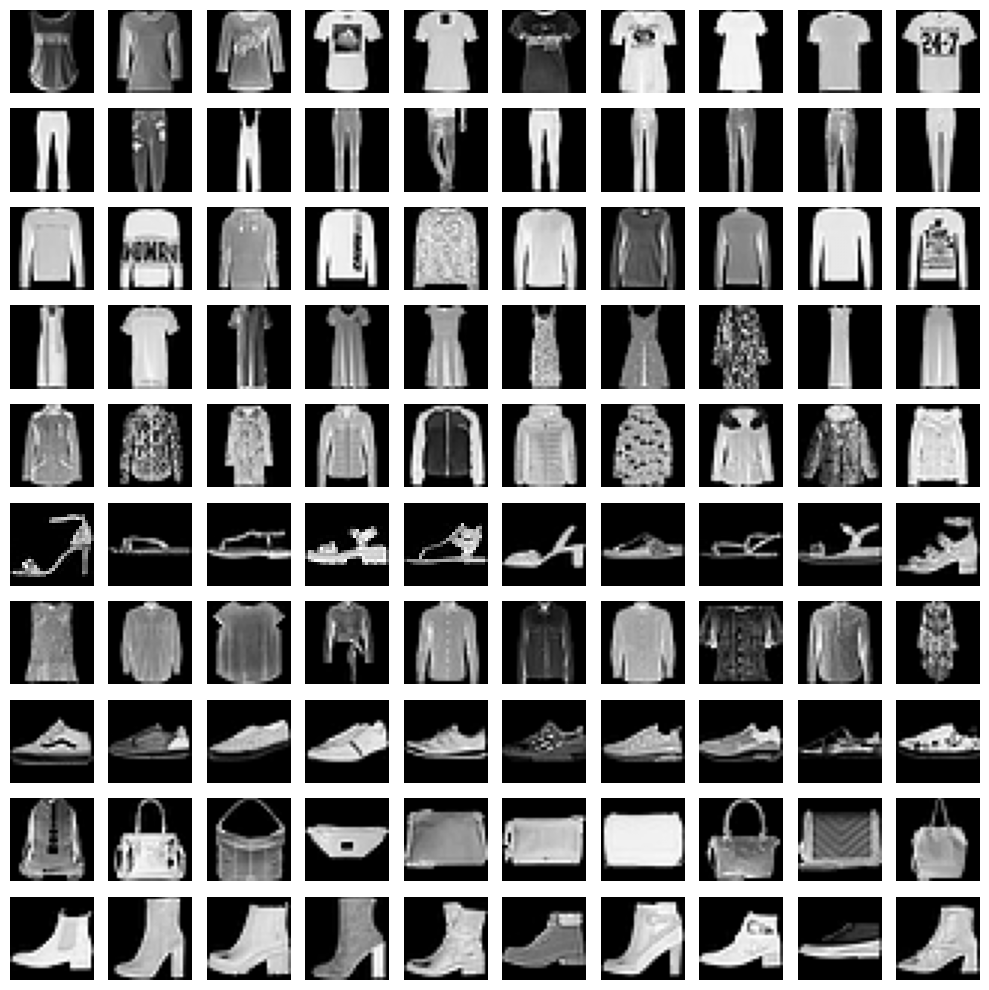

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

R, C = len(tr_targets.unique()), 10
fig, ax = plt.subplots(R, C, figsize=(10,10))

for label_class, plot_row in enumerate(ax):
    label_x_rows = np.where(tr_targets == label_class)[0]

    for plot_cell in plot_row:
        plot_cell.grid(False)
        plot_cell.axis('off')

        ix = np.random.choice(label_x_rows)
        x, y = tr_images[ix], tr_targets[ix]

        plot_cell.imshow(x, cmap='gray')

plt.tight_layout()

In [ ]:
from torchvision import datasets
import torch

data_folder = '/content/data/FMNIST'

fmnist = datasets.FashionMNIST(root=data_folder, train=True, download=True)

tr_images = fmnist.data
tr_targets = fmnist.targets

unique_values = tr_targets.unique()

print(f"""tr_images & tr_targets:
    X - {tr_images.shape}
    Y - {tr_targets.shape}
    Y - Unique Values : {unique_values}

TASK:
    {len(unique_values)} class Classification

UNIQUE CLASSES:
    {fmnist.classes}
""")

tr_images & tr_targets:
    X - torch.Size([60000, 28, 28])
    Y - torch.Size([60000])
    Y - Unique Values : tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

TASK:
    10 class Classification

UNIQUE CLASSES:
    ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']



Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5


/tmp/ipykernel_711/2570480213.py:121: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


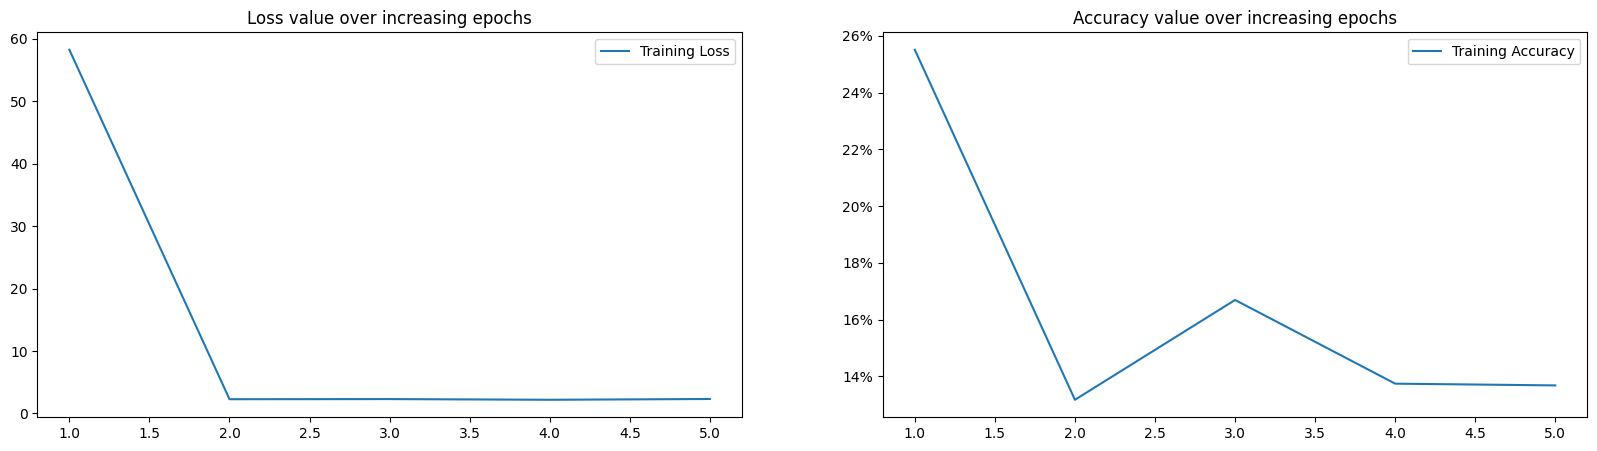

In [ ]:
# Import thư viện
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from torchvision import datasets
from torch.optim import SGD

# Chọn device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load dataset FashionMNIST
data_folder = '/content/data/FMNIST'
fmnist = datasets.FashionMNIST(root=data_folder, train=True, download=True)

tr_images = fmnist.data
tr_targets = fmnist.targets

# Dataset class
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()
        x = x.view(-1, 28*28)
        self.x, self.y = x, y

    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)

# DataLoader
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    return trn_dl

# Model
def get_model():
    model = nn.Sequential(
        nn.Linear(28*28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2)

    return model, loss_fn, optimizer

# Train batch
def train_batch(x, y, model, opt, loss_fn):
    model.train()

    prediction = model(x)
    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()
    opt.step()
    opt.zero_grad()

    return batch_loss.item()

# Accuracy
@torch.no_grad()
def accuracy(x, y, model):
    model.eval()
    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

# Load data
trn_dl = get_data()

# Get model
model, loss_fn, optimizer = get_model()

# Training
losses, accuracies = [], []

for epoch in range(5):
    print("Epoch:", epoch+1)

    epoch_losses, epoch_accuracies = [], []

    for ix, batch in enumerate(trn_dl):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        epoch_losses.append(batch_loss)

    epoch_loss = np.array(epoch_losses).mean()

    for ix, batch in enumerate(trn_dl):
        x, y = batch
        is_correct = accuracy(x, y, model)
        epoch_accuracies.extend(is_correct)

    epoch_accuracy = np.mean(epoch_accuracies)

    losses.append(epoch_loss)
    accuracies.append(epoch_accuracy)

# Plot kết quả
epochs = np.arange(5) + 1

plt.figure(figsize=(20,5))

plt.subplot(121)
plt.title('Loss value over increasing epochs')
plt.plot(epochs, losses, label='Training Loss')
plt.legend()

plt.subplot(122)
plt.title('Accuracy value over increasing epochs')
plt.plot(epochs, accuracies, label='Training Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()

plt.show()

Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5


/tmp/ipykernel_711/594190795.py:126: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


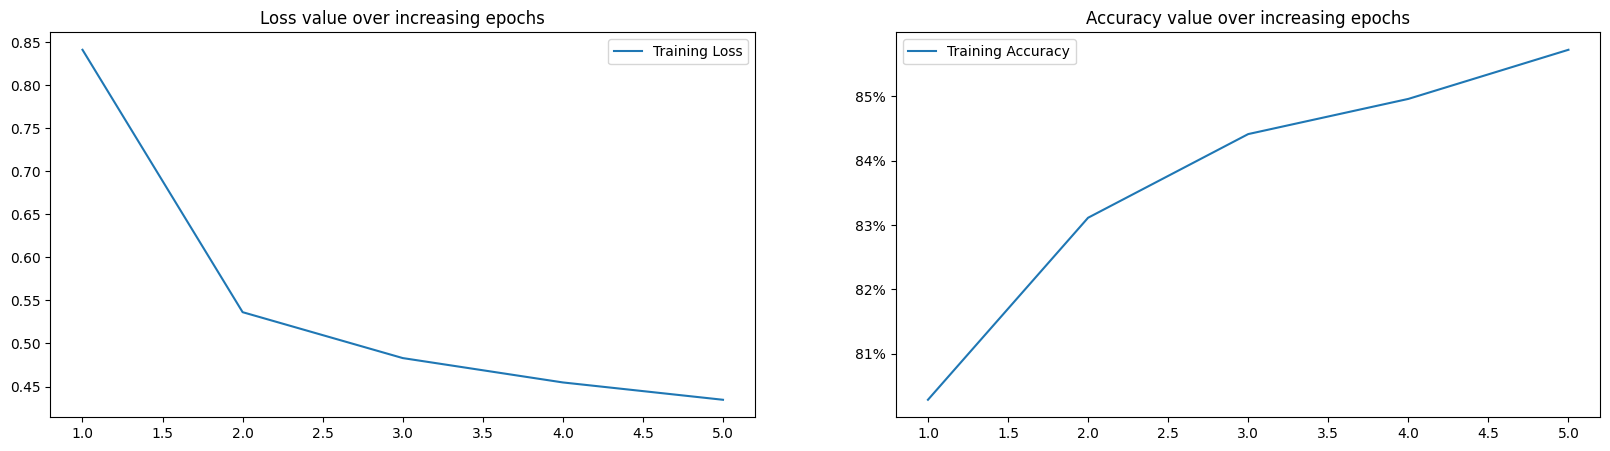

In [ ]:
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load dataset
data_folder = '/content/data/FMNIST'
fmnist = datasets.FashionMNIST(root=data_folder, download=True, train=True)

tr_images = fmnist.data
tr_targets = fmnist.targets


# Dataset class
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28*28)
        self.x, self.y = x, y

    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)


# DataLoader
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    return trn_dl


from torch.optim import SGD

# Model
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2)

    return model, loss_fn, optimizer


# Train batch
def train_batch(x, y, model, opt, loss_fn):
    model.train()

    prediction = model(x)
    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()
    opt.step()
    opt.zero_grad()

    return batch_loss.item()


# Accuracy
def accuracy(x, y, model):
    model.eval()
    with torch.no_grad():
        prediction = model(x)
        max_values, argmaxes = prediction.max(-1)
        is_correct = argmaxes == y
        return is_correct.cpu().numpy().tolist()


# Load data
trn_dl = get_data()

# Model
model, loss_fn, optimizer = get_model()

losses, accuracies = [], []

for epoch in range(5):
    print("Epoch:", epoch+1)

    epoch_losses, epoch_accuracies = [], []

    for ix, batch in enumerate(trn_dl):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        epoch_losses.append(batch_loss)

    epoch_loss = np.array(epoch_losses).mean()

    for ix, batch in enumerate(trn_dl):
        x, y = batch
        is_correct = accuracy(x, y, model)
        epoch_accuracies.extend(is_correct)

    epoch_accuracy = np.mean(epoch_accuracies)

    losses.append(epoch_loss)
    accuracies.append(epoch_accuracy)


# Plot
epochs = np.arange(5) + 1

plt.figure(figsize=(20,5))

plt.subplot(121)
plt.title('Loss value over increasing epochs')
plt.plot(epochs, losses, label='Training Loss')
plt.legend()

plt.subplot(122)
plt.title('Accuracy value over increasing epochs')
plt.plot(epochs, accuracies, label='Training Accuracy')

plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])

plt.legend()
plt.show()

Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5


/tmp/ipykernel_711/1884782610.py:164: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


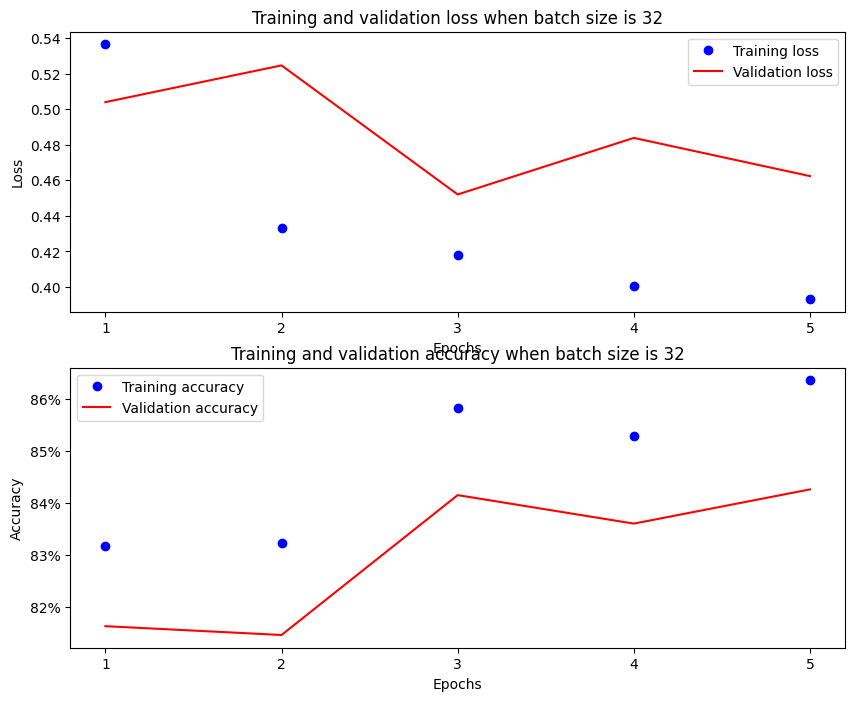

In [ ]:
# Import thư viện
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from torch.optim import Adam

%matplotlib inline

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load dataset
data_folder = '/content/data/FMNIST'

fmnist = datasets.FashionMNIST(root=data_folder, download=True, train=True)
val_fmnist = datasets.FashionMNIST(root=data_folder, download=True, train=False)

tr_images = fmnist.data
tr_targets = fmnist.targets

val_images = val_fmnist.data
val_targets = val_fmnist.targets


# Dataset class
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28*28)
        self.x, self.y = x, y

    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)


# DataLoader
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)

    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)

    return trn_dl, val_dl


# Model
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-2)

    return model, loss_fn, optimizer


# Train batch
def train_batch(x, y, model, opt, loss_fn):
    model.train()

    prediction = model(x)
    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()
    opt.step()
    opt.zero_grad()

    return batch_loss.item()


# Accuracy
def accuracy(x, y, model):
    model.eval()
    with torch.no_grad():
        prediction = model(x)
        _, argmaxes = prediction.max(-1)
        is_correct = argmaxes == y
        return is_correct.cpu().numpy().tolist()


# Validation loss
@torch.no_grad()
def val_loss(x, y, model):
    prediction = model(x)
    v_loss = loss_fn(prediction, y)
    return v_loss.item()


# Load data
trn_dl, val_dl = get_data()

# Model
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

# Training loop
for epoch in range(5):
    print("Epoch:", epoch+1)

    train_epoch_losses, train_epoch_accuracies = [], []

    for batch in trn_dl:
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.mean(train_epoch_losses)

    for batch in trn_dl:
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for batch in val_dl:
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)
        val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)


# Plot kết quả
epochs = np.arange(5) + 1

plt.figure(figsize=(10,8))

plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss when batch size is 32')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)

plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy when batch size is 32')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid(False)

plt.show()

0
1
2
3
4


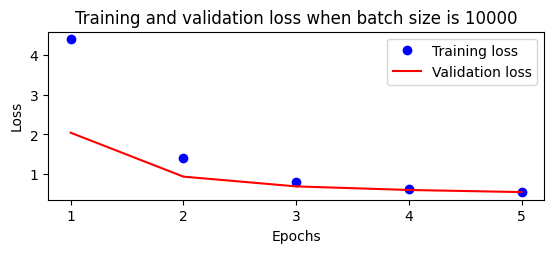

/tmp/ipykernel_711/1926069264.py:84: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


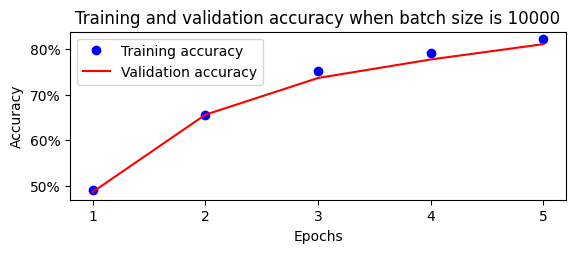

In [ ]:
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=10000, shuffle=True)

    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)

    return trn_dl, val_dl


trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(5):
    print(epoch)

    train_epoch_losses, train_epoch_accuracies = [], []

    # TRAIN
    for ix, batch in enumerate(trn_dl):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(train_epoch_losses).mean()

    # TRAIN ACCURACY
    for ix, batch in enumerate(trn_dl):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    # VALIDATION
    for ix, batch in enumerate(val_dl):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)
        val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)


# Plot
epochs = np.arange(5) + 1

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline

plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation loss when batch size is 10000')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid(False)
plt.show()


plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation accuracy when batch size is 10000')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])

plt.legend()
plt.grid(False)
plt.show()

Epoch: 1
Epoch: 2
Epoch: 3
Epoch: 4
Epoch: 5
Epoch: 6
Epoch: 7
Epoch: 8
Epoch: 9
Epoch: 10


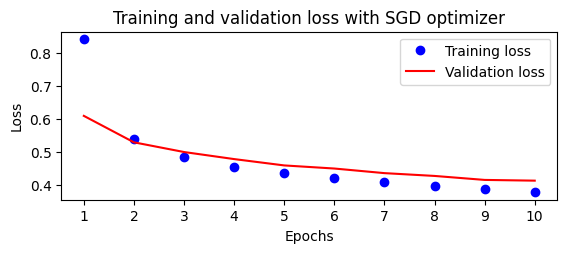

/tmp/ipykernel_711/3836393214.py:178: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


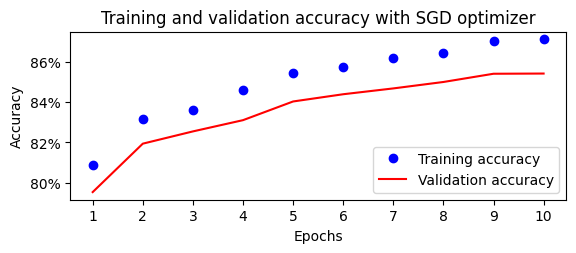

In [ ]:
from torchvision import datasets
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.optim import SGD

%matplotlib inline

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load dataset
data_folder = '/content/data/FMNIST'

fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)

tr_images = fmnist.data
tr_targets = fmnist.targets

val_images = val_fmnist.data
val_targets = val_fmnist.targets


# Dataset class
class FMNISTDataset(Dataset):

    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28*28)
        self.x, self.y = x, y

    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)


# DataLoader
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)

    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)

    return trn_dl, val_dl


# Model
def get_model():

    model = nn.Sequential(
        nn.Linear(28*28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2)

    return model, loss_fn, optimizer


# Train batch
def train_batch(x, y, model, opt, loss_fn):

    model.train()

    prediction = model(x)
    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()
    opt.step()
    opt.zero_grad()

    return batch_loss.item()


# Accuracy
def accuracy(x, y, model):

    model.eval()

    with torch.no_grad():
        prediction = model(x)
        _, argmaxes = prediction.max(-1)
        is_correct = argmaxes == y
        return is_correct.cpu().numpy().tolist()


# Validation loss
@torch.no_grad()
def val_loss(x, y, model):
    prediction = model(x)
    v_loss = loss_fn(prediction, y)
    return v_loss.item()


# Load data
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []


# Training
for epoch in range(10):

    print("Epoch:", epoch+1)

    train_epoch_losses = []
    train_epoch_accuracies = []

    # Train
    for batch in trn_dl:
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.mean(train_epoch_losses)

    # Train accuracy
    for batch in trn_dl:
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    # Validation
    for batch in val_dl:
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)
        val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)


# Plot
epochs = np.arange(10) + 1

plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation loss with SGD optimizer')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid(False)
plt.show()


plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation accuracy with SGD optimizer')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])

plt.legend()
plt.grid(False)
plt.show()

0
1
2
3
4
5
6
7
8
9


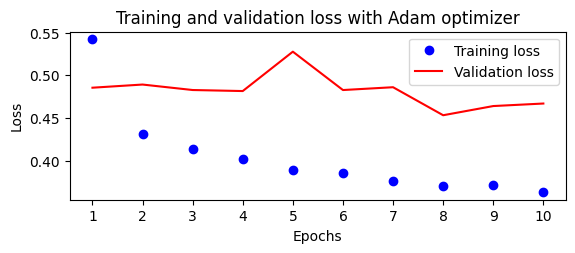

/tmp/ipykernel_711/60811947.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


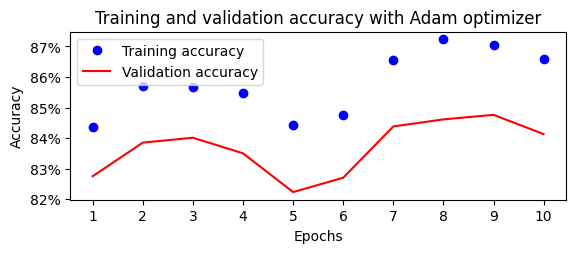

In [ ]:
from torch.optim import SGD, Adam

def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-2)

    return model, loss_fn, optimizer


trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(10):

    print(epoch)

    train_epoch_losses = []
    train_epoch_accuracies = []

    # TRAIN
    for ix, batch in enumerate(trn_dl):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.mean(train_epoch_losses)

    # TRAIN ACCURACY
    for ix, batch in enumerate(trn_dl):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    # VALIDATION
    for ix, batch in enumerate(val_dl):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)
        val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)

    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)


epochs = np.arange(10) + 1

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline


plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation loss with Adam optimizer')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()
plt.grid(False)
plt.show()


plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.title('Training and validation accuracy with Adam optimizer')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])

plt.legend()
plt.grid(False)
plt.show()